# GenCheckAiModel — AI-Generated Image Detection

[GitHub Repository](https://github.com/dimong4/GenCheckAiModel)

This notebook implements an advanced, robust pipeline for detecting AI-generated images using a **Mixture of Experts (MoE)** architecture. It combines features from **ConvNeXt**, **Swin Transformer**, **CLIP**, and the **Frequency Domain** (Azimuthal Power Spectrum), training them via **Metric Learning (Triplet Loss)**.

---

### Dataset & Compliance
* This project was prepared using images generated by the **Yandex Art** model within the *Shedevrum* application.
* The images are provided solely for the research purposes of this project to a *Yandex Lyceum* graduate and are not intended for public/commercial use.
  

In [1]:
!pip install pytorch-metric-learning albumentations grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 99.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.8/127.8 kB 9.9 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=899418f9bf643d250b43229189b2c0aa29d6410fef7f2a1edfe0546934edef03
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


## 1. Setup & Dependencies
Importing required libraries for deep learning, metric learning, and image augmentation.

In [2]:
import os
import io
import copy
import random
import warnings
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from pytorch_metric_learning import losses, miners
from transformers import CLIPProcessor, CLIPModel
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import albumentations as A
from albumentations.pytorch import ToTensorV2

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


2026-07-08 10:57:52.075568: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783508272.271297      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783508272.327489      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783508272.784128      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783508272.784183      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783508272.784187      23 computation_placer.cc:177] computation placer alr

Using device: cuda


## 2. Global Configuration (Hyperparameters)
All configurable hyperparameters, dataset paths, and model settings are centralized here for easy tuning.

In [3]:
class Config:
    # Dataset Paths Dictionary
    PATH_DICT = {
        "kandinskiy": [
            "/kaggle/input/tiny-ai-detect-kandinskiy/dataset/train",
            "/kaggle/input/tiny-ai-detect-kandinskiy/dataset/test",
            "/kaggle/input/tiny-ai-detect-kandinskiy/dataset/val"
        ],
        "yandex": [
            "/kaggle/input/tiny-ai-detect-yandexart/dataset_y/train",
            "/kaggle/input/tiny-ai-detect-yandexart/dataset_y/test",
            "/kaggle/input/tiny-ai-detect-yandexart/dataset_y/val"
        ],
        "biggan": [
            "/kaggle/input/tiny-genimag-biggan/biggan/train",
            "/kaggle/input/tiny-genimag-biggan/biggan/test",
            "/kaggle/input/tiny-genimag-biggan/biggan/val"
        ],
        "ldm": [
            "/kaggle/input/tiny-genimag-ldm/ldm/train",
            "/kaggle/input/tiny-genimag-ldm/ldm/test",
            "/kaggle/input/tiny-genimag-ldm/ldm/val"
        ],
        "stablediffusion": [
            "/kaggle/input/tiny-genimag-stablediffusion/stablediffusion/train",
            "/kaggle/input/tiny-genimag-stablediffusion/stablediffusion/test",
            "/kaggle/input/tiny-genimag-stablediffusion/stablediffusion/val"
        ],
        "glide": [
            "/kaggle/input/tiny-genimag-glide/glide/train",
            "/kaggle/input/tiny-genimag-glide/glide/test",
            "/kaggle/input/tiny-genimag-glide/glide/val"
        ]
    }
    
    # Model Weights
    SWIN_WEIGHTS = "/kaggle/input/swin-t-ai-check/pytorch/default/1/swin-t_model_checkpoint.pth"
    CLIP_MODEL_NAME = "/kaggle/input/clip/transformers/default/1"  # Local HuggingFace Path
    
    # Dataloader Settings
    BATCH_SIZE_EXTRACT = 10
    BATCH_SIZE_MLP = 128
    
    # Metric Learning Hyperparameters
    EPOCHS_MLP = 15
    MLP_LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-2
    TRIPLET_MARGIN = 0.3
    
    # Mixture of Experts (MoE) Architecture
    MOE_NUM_EXPERTS = 8
    MOE_HIDDEN_DIM = 512
    MOE_DROPOUT = 0.3
    MOE_BALANCING_WEIGHT = 0.1
    
    # Robust Augmentation Probability
    AUGMENTATION_PROB = 0.5
    
    # Visualization & Inference
    INFERENCE_TEMPERATURE = 10.0


## 3. Robust Data Augmentation Pipeline
Custom augmentations to simulate degradations like JPEG compression, downscaling, and noise. This prevents the model from overfitting to low-level pixel artifacts.

In [4]:
class RandomJPEG(object):
    def __init__(self, quality_range=(30, 90), p=0.5):
        self.quality_range = quality_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        quality = random.randint(*self.quality_range)
        buffer = io.BytesIO()
        img.save(buffer, format="JPEG", quality=quality)
        buffer.seek(0)
        return Image.open(buffer)


class RandomDownscale(object):
    def __init__(self, scale_range=(0.5, 0.8), p=0.5):
        self.scale_range = scale_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        scale = random.uniform(*self.scale_range)
        w, h = img.size
        img_down = img.resize((int(w * scale), int(h * scale)), Image.BILINEAR)
        return img_down.resize((w, h), Image.BILINEAR)


class RandomGaussianNoise(object):
    def __init__(self, std_range=(0.01, 0.1), p=0.5):
        self.std_range = std_range
        self.p = p

    def __call__(self, tensor):
        if random.random() > self.p:
            return tensor
        std = random.uniform(*self.std_range)
        noise = torch.randn_like(tensor) * std
        return torch.clamp(tensor + noise, 0, 1)


def load_data(path_dict, batch_size=10):
    train_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomApply(
            [transforms.ColorJitter(hue=0.1, brightness=0.2, contrast=0.2)], 
            p=Config.AUGMENTATION_PROB
        ),
        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=5, sigma=(0.5, 3.0))], 
            p=Config.AUGMENTATION_PROB
        ),
        RandomJPEG(quality_range=(30, 90), p=Config.AUGMENTATION_PROB),
        RandomDownscale(scale_range=(0.5, 0.8), p=Config.AUGMENTATION_PROB),
        transforms.ToTensor(),
        RandomGaussianNoise(std_range=(0.01, 0.1), p=Config.AUGMENTATION_PROB),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    test_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    train_datasets = []
    valid_datasets = []
    test_datasets = []

    for model_name, paths in path_dict.items():
        if os.path.exists(paths[0]):
            train_datasets.append(datasets.ImageFolder(paths[0], transform=train_transforms))
        if os.path.exists(paths[2]):
            valid_datasets.append(datasets.ImageFolder(paths[2], transform=test_transforms))
        if os.path.exists(paths[1]):
            test_datasets.append(datasets.ImageFolder(paths[1], transform=test_transforms))

    train_dataset = torch.utils.data.ConcatDataset(train_datasets)
    valid_dataset = torch.utils.data.ConcatDataset(valid_datasets)
    test_dataset = torch.utils.data.ConcatDataset(test_datasets)
    
    train_dataloader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, drop_last=True
    )
    valid_dataloader = DataLoader(
        valid_dataset, batch_size=batch_size, shuffle=False
    )
    test_dataloader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False
    )

    return train_dataloader, valid_dataloader, test_dataloader

train_dataloader, valid_dataloader, test_dataloader = load_data(
    Config.PATH_DICT, 
    batch_size=Config.BATCH_SIZE_EXTRACT
)


## 4. Feature Extractor Initialization
Initializing ConvNeXt (visual artifacts), Swin Transformer (global structure), and CLIP (semantic mismatches).

In [5]:
# --- ConvNeXt Backbone ---
class ContrastiveNetConvNext(nn.Module):
    def __init__(self):
        super(ContrastiveNetConvNext, self).__init__()
        self.backbone = models.convnext_tiny(
            weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        )
        # Remove classification head to get embeddings directly
        self.backbone.classifier = nn.Identity()

    def forward(self, x):
        features = self.backbone(x)
        features = torch.flatten(features, 1)
        return F.normalize(features, p=2, dim=1)

model_con = ContrastiveNetConvNext().to(device)

# --- Swin Transformer Backbone ---
try:
    swin = torch.load(Config.SWIN_WEIGHTS, map_location=device, weights_only=False)
    print("Swin loaded completely from local path.")
except FileNotFoundError:
    print("Local Swin model not found. Using default structure...")
    swin = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1)

swin.head = nn.Identity()
swin = swin.to(device)
swin.eval()

# --- CLIP Backbone ---
try:
    clip_model = CLIPModel.from_pretrained(Config.CLIP_MODEL_NAME).to(device)
    clip_processor = CLIPProcessor.from_pretrained(Config.CLIP_MODEL_NAME)
    print("CLIP loaded successfully.")
except Exception as e:
    print(f"Failed to load CLIP: {e}")

clip_model.eval()


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 211MB/s]


Swin loaded completely from local path.


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


CLIP loaded successfully.


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

## 5. Frequency Domain Analysis
Extracting the Azimuthal Average Power Spectrum (AAPS) to capture high-frequency artifacts left by diffusion models.

In [6]:
def get_azimuthal_average_power_spectrum(image_tensor):
    batch_size = image_tensor.size(0)
    gray_images = (
        0.2989 * image_tensor[:, 0, :, :] + 
        0.5870 * image_tensor[:, 1, :, :] + 
        0.1140 * image_tensor[:, 2, :, :]
    )
    
    f_transform = torch.fft.fft2(gray_images)
    f_shift = torch.fft.fftshift(f_transform, dim=(-2, -1))
    magnitude_spectrum = torch.abs(f_shift) ** 2

    h, w = magnitude_spectrum.shape[1], magnitude_spectrum.shape[2]
    y, x = torch.meshgrid(torch.arange(h), torch.arange(w), indexing="ij")
    center_y, center_x = h // 2, w // 2
    y = y.to(device)
    x = x.to(device)
    
    radii = torch.sqrt((x - center_x) ** 2 + (y - center_y) ** 2)
    radii = radii.to(torch.int32)
    
    max_radius = torch.max(radii).item()
    aaps = torch.zeros((batch_size, max_radius + 1), device=device)
    
    for i in range(batch_size):
        mag = magnitude_spectrum[i]
        bincount = torch.bincount(radii.flatten(), weights=mag.flatten())
        counts = torch.bincount(radii.flatten())
        counts[counts == 0] = 1
        aaps[i, :len(bincount)] = bincount / counts

    aaps = torch.log1p(aaps)
    aaps = F.normalize(aaps, p=2, dim=1)
    return aaps


## 6. Feature Extraction Loop
Extracting and concatenating all features into a single unified embedding space matrix.

In [7]:
def extract_features_final(dataloader):
    features_list = []
    labels_list = []
    model_con.eval()
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting Features"):
            images = images.to(device)
            
            emb_convnext = model_con.backbone(images).flatten(1)
            emb_swin = swin(images)
            
            images_resized = F.interpolate(
                images, size=(224, 224), mode="bicubic"
            )
            emb_clip = clip_model.get_image_features(
                pixel_values=images_resized
            )
            
            freq_features = get_azimuthal_average_power_spectrum(images)
            
            f1 = emb_convnext.cpu().numpy()
            f2 = emb_swin.cpu().numpy()
            f3 = emb_clip.cpu().numpy()
            f4 = freq_features.cpu().numpy()
            
            batch_features = np.concatenate([f1, f2, f3, f4], axis=1)
            features_list.append(batch_features)
            labels_list.append(labels.numpy())
            
    return np.concatenate(features_list, axis=0), np.concatenate(labels_list, axis=0)

X_train_new, y_train_new = extract_features_final(train_dataloader)
X_test_new, y_test_new = extract_features_final(test_dataloader)

X_train_t = torch.tensor(X_train_new, dtype=torch.float32)
y_train_t = torch.tensor(y_train_new, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test_new, dtype=torch.float32)
y_test_t = torch.tensor(y_test_new, dtype=torch.float32).unsqueeze(1)

train_dataset_mlp = torch.utils.data.TensorDataset(X_train_t, y_train_t)
train_loader_mlp = torch.utils.data.DataLoader(
    train_dataset_mlp, 
    batch_size=Config.BATCH_SIZE_MLP, 
    shuffle=True
)


Extracting Features: 100%|██████████| 188/188 [00:50<00:00,  3.74it/s]


## 7. Mixture of Experts (MoE) Architecture
A router directs different input patterns to specialized sub-networks (experts), enabling the model to handle diverse image modalities effectively.

In [8]:
class Expert(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64)
        )
        
    def forward(self, x):
        return self.net(x)

class MixtureOfExperts(nn.Module):
    def __init__(self, input_dim, num_experts=4, hidden_dim=512, dropout=0.3):
        super().__init__()
        self.num_experts = num_experts
        self.experts = nn.ModuleList([
            Expert(input_dim, hidden_dim, dropout) for _ in range(num_experts)
        ])
        self.router = nn.Linear(input_dim, num_experts)
        
    def forward(self, x):
        gates = F.softmax(self.router(x), dim=1)
        
        importance = gates.mean(dim=0)
        loss_bal = self.num_experts * torch.sum(importance ** 2) - 1.0
        
        expert_outputs = torch.stack(
            [expert(x) for expert in self.experts], dim=1
        )
        output = torch.sum(gates.unsqueeze(-1) * expert_outputs, dim=1)
        
        return F.normalize(output, p=2, dim=1), loss_bal

mlp_model = MixtureOfExperts(
    input_dim=X_train_t.shape[1], 
    num_experts=Config.MOE_NUM_EXPERTS,
    hidden_dim=Config.MOE_HIDDEN_DIM,
    dropout=Config.MOE_DROPOUT
).to(device)


## 8. Metric Learning (Triplet Loss)
Training the MoE model to cluster "Real" images together and push "AI" images away in the embedding space.


In [9]:
criterion = losses.TripletMarginLoss(margin=Config.TRIPLET_MARGIN)
miner = miners.TripletMarginMiner(
    margin=Config.TRIPLET_MARGIN, type_of_triplets="semihard"
)
optimizer_mlp = optim.AdamW(
    mlp_model.parameters(), 
    lr=Config.MLP_LEARNING_RATE, 
    weight_decay=Config.WEIGHT_DECAY
)

print("Training Mixture of Experts...")
for epoch in range(Config.EPOCHS_MLP):
    mlp_model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader_mlp:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer_mlp.zero_grad()
        
        out, loss_bal = mlp_model(batch_X)
        hard_pairs = miner(out, batch_y.squeeze(-1).long())
        loss_triplet = criterion(out, batch_y.squeeze(-1).long(), hard_pairs)
        
        loss = loss_triplet + Config.MOE_BALANCING_WEIGHT * loss_bal
        loss.backward()
        optimizer_mlp.step()
        total_loss += loss.item()
        
    print(f"MoE Epoch {epoch+1}/{Config.EPOCHS_MLP} Loss: {total_loss / len(train_loader_mlp):.4f}")

torch.save(mlp_model.state_dict(), "ensemble_moe.pth")


Training Mixture of Experts...
MoE Epoch 1/15 Loss: 0.1502
MoE Epoch 2/15 Loss: 0.1576
MoE Epoch 3/15 Loss: 0.1496
MoE Epoch 4/15 Loss: 0.1607
MoE Epoch 5/15 Loss: 0.1584
MoE Epoch 6/15 Loss: 0.1590
MoE Epoch 7/15 Loss: 0.1482
MoE Epoch 8/15 Loss: 0.1547
MoE Epoch 9/15 Loss: 0.1577
MoE Epoch 10/15 Loss: 0.1567
MoE Epoch 11/15 Loss: 0.1437
MoE Epoch 12/15 Loss: 0.1351
MoE Epoch 13/15 Loss: 0.1481
MoE Epoch 14/15 Loss: 0.1559
MoE Epoch 15/15 Loss: 0.1406


## 9. Inference & Centroid Distance Evaluation
Calculating the distance from test embeddings to the training class centroids to predict labels.

                  precision    recall  f1-score   support

AI Generated (0)     0.9898    1.0000    0.9949       970
  Real Photo (1)     1.0000    0.9890    0.9945       910

        accuracy                         0.9947      1880
       macro avg     0.9949    0.9945    0.9947      1880
    weighted avg     0.9947    0.9947    0.9947      1880

ROC-AUC Score: 0.9999
------------------------------


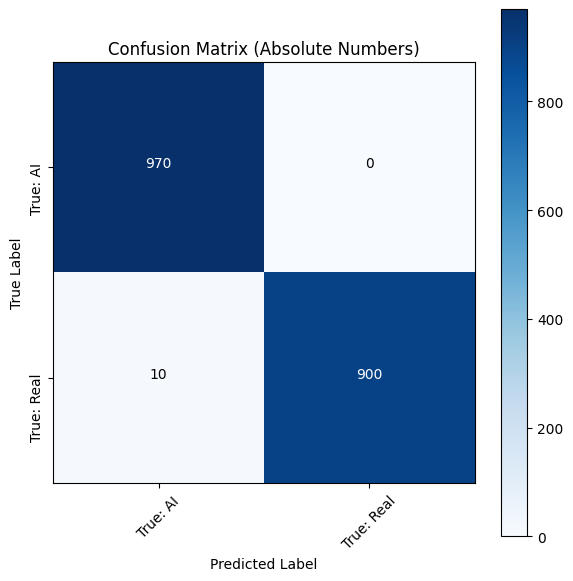

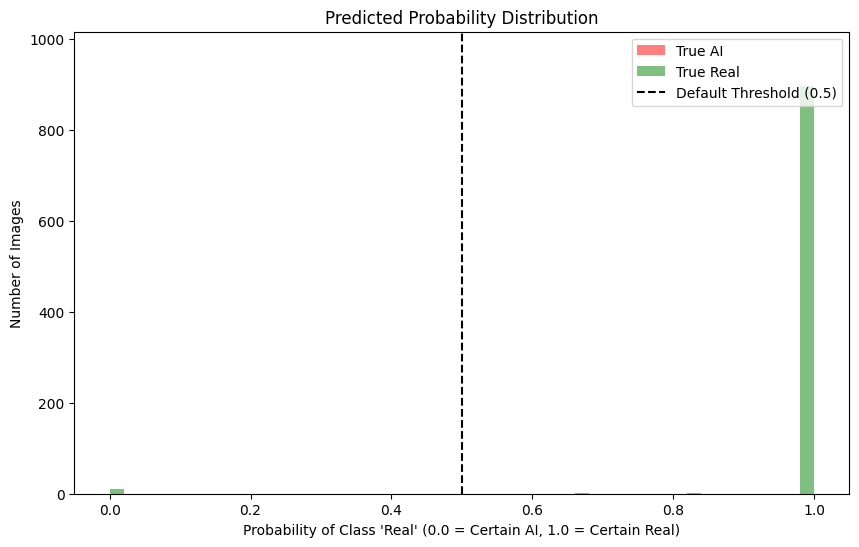

Errors: 10 out of 1880


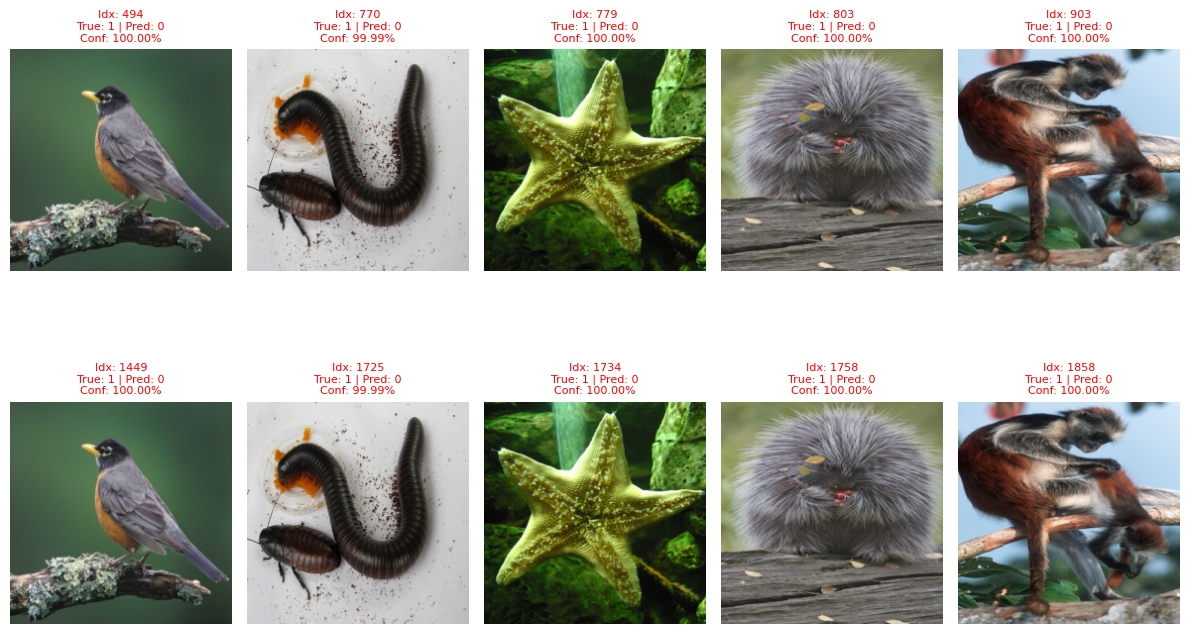

In [10]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def unnormalize(tensor):
    return (tensor.cpu() * std + mean).clamp(0, 1)

mlp_model.eval()
with torch.no_grad():
    train_embs, _ = mlp_model(X_train_t.to(device))
    train_embs = train_embs.cpu()
    test_embs, _ = mlp_model(X_test_t.to(device))
    test_embs = test_embs.cpu()

    centroid_0 = train_embs[y_train_new == 0].mean(dim=0)
    centroid_1 = train_embs[y_train_new == 1].mean(dim=0)

    sim_0 = F.cosine_similarity(test_embs, centroid_0.unsqueeze(0))
    sim_1 = F.cosine_similarity(test_embs, centroid_1.unsqueeze(0))

    logits = torch.stack([sim_0, sim_1], dim=1) * Config.INFERENCE_TEMPERATURE
    probs_final = torch.softmax(logits, dim=1).numpy()
    preds_final = np.argmax(probs_final, axis=1)

print(classification_report(
    y_test_new, preds_final, digits=4, 
    target_names=["AI Generated (0)", "Real Photo (1)"]
))

roc_auc = roc_auc_score(y_test_new, probs_final[:, 1])
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("-" * 30)

cm = confusion_matrix(y_test_new, preds_final)
plt.figure(figsize=(6, 6))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Absolute Numbers)")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["True: AI", "True: Real"], rotation=45)
plt.yticks(tick_marks, ["True: AI", "True: Real"], rotation=90)

thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(
        j, i, format(cm[i, j], "d"),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black"
    )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# Histogram
plt.figure(figsize=(10, 6))
plt.hist(probs_final[y_test_new == 0][:, 1], bins=50, alpha=0.5, color="red", label="True AI")
plt.hist(probs_final[y_test_new == 1][:, 1], bins=50, alpha=0.5, color="green", label="True Real")
plt.axvline(0.5, color="black", linestyle="dashed", label="Default Threshold (0.5)")
plt.xlabel("Probability of Class 'Real' (0.0 = Certain AI, 1.0 = Certain Real)")
plt.ylabel("Number of Images")
plt.title("Predicted Probability Distribution")
plt.legend()
plt.show()

# Visualize Mistakes
mistakes_idx = np.where(preds_final != y_test_new)[0]
print(f"Errors: {len(mistakes_idx)} out of {len(y_test_new)}")

if len(mistakes_idx) > 0:
    plt.figure(figsize=(12, 8))
    for i, idx in enumerate(mistakes_idx[:10]):
        img_tensor, _ = test_dataloader.dataset[idx]
        img_show = unnormalize(img_tensor).permute(1, 2, 0).numpy()
        
        plt.subplot(2, 5, i + 1)
        plt.imshow(img_show)
        pred_label = preds_final[idx]
        true_label = y_test_new[idx]
        prob = probs_final[idx, pred_label] * 100
        
        plt.title(
            f"Idx: {idx}\nTrue: {int(true_label)} | Pred: {pred_label}\nConf: {prob:.2f}%", 
            color="red", fontsize=8
        )
        plt.axis("off")
    plt.tight_layout()
    plt.show()


## 10. Robustness Stress Testing
Testing how well the model handles deliberate image degradations not explicitly trained on.


In [11]:
def apply_jpeg_compression(img_tensor, quality=50):
    img_pil = transforms.ToPILImage()(img_tensor.cpu())
    buffer = io.BytesIO()
    img_pil.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    img_compressed = Image.open(buffer)
    tensor_compressed = transforms.ToTensor()(img_compressed)
    tensor_normalized = transforms.Normalize(
        [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
    )(tensor_compressed)
    return tensor_normalized

def apply_gaussian_blur(img_tensor, kernel_size=5, sigma=1.0):
    blur = transforms.GaussianBlur(kernel_size=kernel_size, sigma=sigma)
    return blur(img_tensor)

def test_robustness(dataloader, clf_model, centroid_0, centroid_1, transform_func, **kwargs):
    print(f"\n--- Stress Testing ---")
    clf_model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images_pert = torch.stack(
                [transform_func(img, **kwargs) for img in images]
            ).to(device)

            emb_convnext = model_con.backbone(images_pert).flatten(1)
            emb_swin = swin(images_pert)
            
            images_resized = F.interpolate(
                images_pert, size=(224, 224), mode="bicubic"
            )
            emb_clip = clip_model.get_image_features(pixel_values=images_resized)
            
            freq_features = get_azimuthal_average_power_spectrum(images_pert)

            f1 = emb_convnext.cpu().numpy()
            f2 = emb_swin.cpu().numpy()
            f3 = emb_clip.cpu().numpy()
            f4 = freq_features.cpu().numpy()

            X_pert = np.concatenate([f1, f2, f3, f4], axis=1)
            X_pert_t = torch.tensor(X_pert, dtype=torch.float32).to(device)
            
            pert_embs, _ = clf_model(X_pert_t)
            pert_embs = pert_embs.cpu()
            
            sim_0 = F.cosine_similarity(pert_embs, centroid_0.unsqueeze(0))
            sim_1 = F.cosine_similarity(pert_embs, centroid_1.unsqueeze(0))
            
            preds = (sim_1 > sim_0).numpy().astype(int)
            correct += (preds == labels.numpy()).sum()
            total += labels.size(0)

    acc = correct / total
    return acc

acc_jpeg = test_robustness(
    test_dataloader, mlp_model, centroid_0, centroid_1, 
    apply_jpeg_compression, quality=30
)
print(f"\nAccuracy with JPEG 30: {acc_jpeg * 100:.2f}%")

acc_blur = test_robustness(
    test_dataloader, mlp_model, centroid_0, centroid_1, 
    apply_gaussian_blur, kernel_size=9, sigma=3.0
)
print(f"\nAccuracy with Gaussian Blur (sigma=3): {acc_blur * 100:.2f}%")



--- Stress Testing ---


100%|██████████| 188/188 [00:44<00:00,  4.26it/s]



Accuracy with JPEG 30: 75.27%

--- Stress Testing ---


100%|██████████| 188/188 [00:44<00:00,  4.26it/s]


Accuracy with Gaussian Blur (sigma=3): 97.07%


## 11. Explainable AI (Grad-CAM Visualizations)
Visualizing which features the model relies on using Class Activation Mapping.


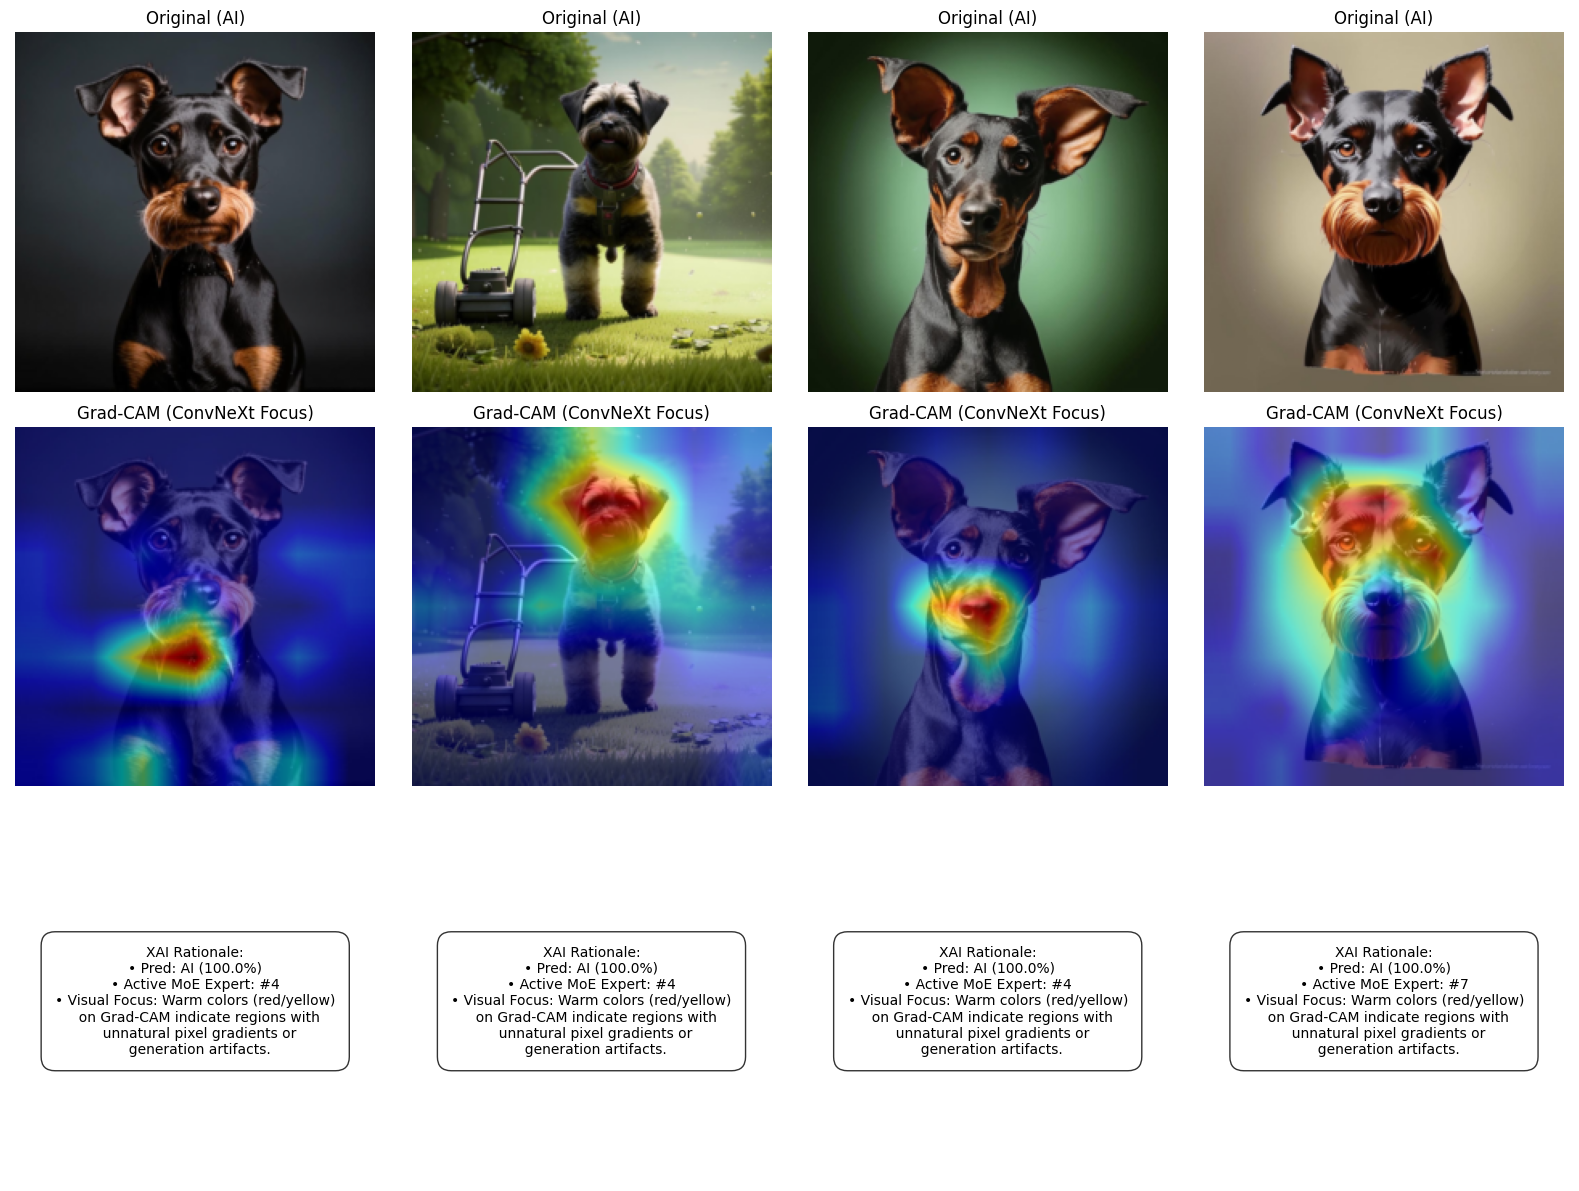

In [ ]:
class FullPipelineForCAM(nn.Module):
    def __init__(self, convnext_model, swin_model, clip_model, mlp_model, centroid_0, centroid_1):
        super().__init__()
        self.convnext = convnext_model
        self.swin = swin_model
        self.clip_model = clip_model
        self.mlp_model = mlp_model
        self.centroid_0 = centroid_0
        self.centroid_1 = centroid_1

    def forward(self, x):
        emb_convnext = self.convnext.backbone(x).flatten(1)
        
        with torch.no_grad():
            emb_swin = self.swin(x)
            images_resized = F.interpolate(x, size=(224, 224), mode="bicubic")
            emb_clip = self.clip_model.get_image_features(pixel_values=images_resized)
            freq_features = get_azimuthal_average_power_spectrum(x)
        
        batch_features = torch.cat(
            [emb_convnext, emb_swin, emb_clip, freq_features], dim=1
        )
        
        pert_embs, _ = self.mlp_model(batch_features)
        
        sim_0 = F.cosine_similarity(pert_embs, self.centroid_0.to(device).unsqueeze(0))
        sim_1 = F.cosine_similarity(pert_embs, self.centroid_1.to(device).unsqueeze(0))
        
        logits = torch.stack([sim_0, sim_1], dim=1) * Config.INFERENCE_TEMPERATURE
        return logits

cam_model = FullPipelineForCAM(
    model_con, swin, clip_model, mlp_model, 
    centroid_0.to(device), centroid_1.to(device)
)
cam_model.eval()

target_layers = [model_con.backbone.features[-1]]
cam = GradCAM(model=cam_model, target_layers=target_layers)

sample_inputs, sample_labels = next(iter(test_dataloader))
sample_inputs = sample_inputs[:4].to(device)
sample_labels = sample_labels[:4]

targets = [ClassifierOutputTarget(label.item()) for label in sample_labels]
grayscale_cam = cam(input_tensor=sample_inputs, targets=targets)

# Get probabilities and active expert to explain the decision
with torch.no_grad():
    emb_convnext = model_con.backbone(sample_inputs).flatten(1)
    emb_swin = swin(sample_inputs)
    images_resized = F.interpolate(sample_inputs, size=(224, 224), mode="bicubic")
    emb_clip = clip_model.get_image_features(pixel_values=images_resized)
    freq_features = get_azimuthal_average_power_spectrum(sample_inputs)
    
    batch_features = torch.cat([emb_convnext, emb_swin, emb_clip, freq_features], dim=1)
    pert_embs, _ = mlp_model(batch_features)
    
    # Identify which expert in the MoE was responsible for this image
    gates = F.softmax(mlp_model.router(batch_features), dim=1)
    active_experts = torch.argmax(gates, dim=1)
    
    sim_0 = F.cosine_similarity(pert_embs, centroid_0.to(device).unsqueeze(0))
    sim_1 = F.cosine_similarity(pert_embs, centroid_1.to(device).unsqueeze(0))
    logits = torch.stack([sim_0, sim_1], dim=1) * Config.INFERENCE_TEMPERATURE
    probs = torch.softmax(logits, dim=1).cpu().numpy()

plt.figure(figsize=(16, 12))
for i in range(4):
    img_tensor = sample_inputs[i]
    img_show = unnormalize(img_tensor).permute(1, 2, 0).cpu().numpy()

    cam_image = show_cam_on_image(img_show, grayscale_cam[i, :], use_rgb=True)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img_show)
    label_str = "Real" if sample_labels[i].item() == 1 else "AI"
    plt.title(f"Original ({label_str})")
    plt.axis("off")

    plt.subplot(3, 4, i + 5)
    plt.imshow(cam_image)
    plt.title("Grad-CAM (ConvNeXt Focus)")
    plt.axis("off")
    
    # XAI Text Explanation
    plt.subplot(3, 4, i + 9)
    plt.axis("off")
    
    pred_class = "Real" if probs[i, 1] > 0.5 else "AI"
    conf = max(probs[i]) * 100
    expert_idx = active_experts[i].item()
    
    explanation_text = (
        f"XAI Rationale:\n"
        f"• Pred: {pred_class} ({conf:.1f}%)\n"
        f"• Active MoE Expert: #{expert_idx}\n"
        f"• Visual Focus: Warm colors (red/yellow)\n"
        f"  on Grad-CAM indicate regions with\n"
        f"  unnatural pixel gradients or\n"
        f"  generation artifacts."
    )
    plt.text(0.5, 0.5, explanation_text, fontsize=10, 
             horizontalalignment="center", verticalalignment="center",
             bbox=dict(facecolor="white", alpha=0.8, edgecolor="black", boxstyle="round,pad=1"))

plt.tight_layout()
plt.show()
